# Author Info
---
Name: **Ejaz-ur-Rehman**\
Business Unit Head | Data Analyst\
MBA (Accounting & Finance), MS (Finance)\
Crystal Tech (Project of MUZHAB Group)\
Karachi, Pakistan

![Date](https://img.shields.io/badge/Date-04--September--2025-green?logo=google-calendar)
[![Email](https://img.shields.io/badge/Email-ijazfinance%40gmail.com-blue?logo=gmail)](mailto:ijazfinance@gmail.com)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Ejaz--ur--Rehman-blue?logo=linkedin)](https://www.linkedin.com/in/ejaz-ur-rehman/)
[![GitHub](https://img.shields.io/badge/GitHub-ejazurrehman-black?logo=github)](https://github.com/ejazurrehman)

# What are Divisibility Rules?
---

- Divisibility rules are quick tests to determine if one number divides another without actually performing division.
- For example:
  - A number is divisible by 2 if its last digit is even.
  - A number is divisible by 3 if the sum of its digits is divisible by 3.
  - A number is divisible by 5 if its last digit is 0 or 5.

- In math, these are shortcuts.
  - In data science, they appear as efficient ways of partitioning, hashing, sampling, or validating numbers.

## Role of Divisibility Rules in Data Science
---

- Here’s how they matter in practice:

## 1) Efficient Data Partitioning
- Suppose we’re splitting a dataset of 1,000,000 rows across processors.
- If each processor must handle 200,000 rows, we can check divisibility quickly (e.g., 1,000,000 ÷ 200,000 = 5 → no remainder).
- Divisibility rules help to design balanced batch jobs.

## 2) Feature Engineering / Data Validation

- Example: Credit card numbers use divisibility checks (part of the Luhn algorithm) to validate input.
- In datasets with IDs, checking divisibility patterns can detect corruption, entry errors, or fraud.

## 3) Hashing and Bucketing

- Many hashing systems rely on modular arithmetic (id % bucket_size).
- If the bucket size has divisibility properties (like powers of 2), lookup becomes faster.
- Choosing prime vs composite bucket sizes ties back to divisibility.

## 4) Sampling and Random Splits

- In stratified sampling, divisibility checks can quickly decide if a row index goes into test or training data.
- Example: “Every 10th row goes to the test set.” → Rule: divisible by 10.

## 5) Signal Processing & FFT

- Fast Fourier Transform (FFT) efficiency depends on input sizes that are divisible by powers of 2 (or small primes).
- Divisibility rules ensure that padding or resizing data keeps algorithms efficient.

## 6) Scheduling and Workflows

- If Task A runs every 12 minutes and Task B every 18 minutes → the overlap happens when the clock time is divisible by LCM(12,18)=36.
- Divisibility rules help in task orchestration.

# Case Study: Divisibility Rules in Data Science
---

## Problem Statement:
- We manage a dataset of 1,000 IoT sensor readings. We need to:
  - Split data efficiently into training/test sets using divisibility rules.
  - Schedule jobs (backup every 12 mins, update every 18 mins) → use LCM divisibility.
  - Optimize an FFT analysis by padding the dataset length to a size divisible by a power of 2.

## Step 1: Generate Synthetic Dataset

In [1]:
import numpy as np
import pandas as pd

# Create dataset of 1000 IoT readings
np.random.seed(0)
df = pd.DataFrame({
    "id": np.arange(1, 1001),
    "reading": np.random.normal(72, 5, 1000)  # fake sensor readings
})

print(df.head())


   id    reading
0   1  80.820262
1   2  74.000786
2   3  76.893690
3   4  83.204466
4   5  81.337790


## Step 2: Partition Data with Divisibility (Train/Test Split)
- Rule: If id is divisible by 5, assign to test set, else training set.

In [2]:
df["set"] = np.where(df["id"] % 5 == 0, "test", "train")

print(df["set"].value_counts())


set
train    800
test     200
Name: count, dtype: int64


📌 This ensures exactly 20% test and 80% train without randomness.
This is useful for reproducible splits.

## Step 3: Scheduling with LCM (Workflow Orchestration)
- Backup runs every 12 mins
- Update runs every 18 mins
- They align when time is divisible by LCM(12,18)=36

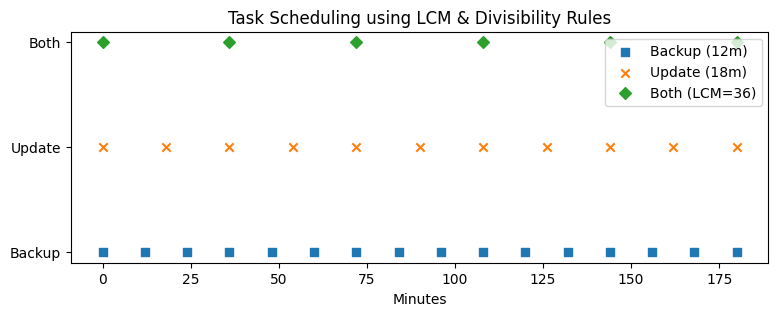

In [3]:
import matplotlib.pyplot as plt
import math

backup = 12
update = 18
lcm_val = abs(backup*update)//math.gcd(backup,update)

timeline = np.arange(0, 181, 1)
backup_times = timeline[timeline % backup == 0]
update_times = timeline[timeline % update == 0]
both_times   = timeline[timeline % lcm_val == 0]

plt.figure(figsize=(9,3))
plt.scatter(backup_times, [0]*len(backup_times), label="Backup (12m)", marker="s")
plt.scatter(update_times, [1]*len(update_times), label="Update (18m)", marker="x")
plt.scatter(both_times,   [2]*len(both_times),   label=f"Both (LCM={lcm_val})", marker="D")
plt.yticks([0,1,2], ["Backup","Update","Both"])
plt.xlabel("Minutes")
plt.title("Task Scheduling using LCM & Divisibility Rules")
plt.legend()
plt.show()


📌 Divisibility ensures we know exactly when tasks align → prevents workflow conflicts.

## Step 4: FFT Efficiency with Divisibility

- FFT is fastest when data length is divisible by a power of 2.

In [4]:
# Example signal (950 points, not divisible by power of 2)
N_raw = 950
signal = np.sin(2*np.pi*0.1*np.arange(N_raw)) + np.random.normal(0,0.2,N_raw)

# Next power of 2 (1024)
N_pad = 1 << (N_raw-1).bit_length()
signal_pad = np.pad(signal, (0, N_pad-N_raw))

print("Raw length:", N_raw, "→ Padded length:", N_pad)


Raw length: 950 → Padded length: 1024


📌 Divisibility by 2 speeds up FFT, saving computation time in signal processing pipelines.

## Takeaway

- Divisibility rules help in data science by:
  - Partitioning data (train/test split without randomness)
  - Orchestrating tasks (LCM for workflow scheduling)
  - Optimizing algorithms (FFT with lengths divisible by 2)